In [1]:
import pysam
from collections import Counter
import numpy as np
import pandas as pd
import pysam.samtools
import glob
import os 
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#place raw files into raw directory>casenumberdirectory>
#run this to check they are there and named correctly for the pipeline to function
#will find the pairs 
import glob, os, pandas as pd

# SELECT CASES HERE (edit list)
selected_cases = ["Case_0080", "Case_0876", "Case_CTRL"]  # Add/remove cases

#input the postiions of mutations you are interested in 
positions = {
    "Case_0080": ["2:25462012"],
    "Case_0876": ["2:25462017"], 
    "Case_CTRL": ["2:25462012", "2:25462017"]
}

base_dir = "/mnt/claw-raid/elliot/P001_CHIP/Data/raw"
all_fastqs = []

for case_name in selected_cases:
    case_path = glob.glob(f"{base_dir}/{case_name}/**/*L001_ds.*", recursive=True)
    for sdir in case_path:
        # Sample from dir name
        sample_full = os.path.basename(os.path.dirname(sdir))
        sample = sample_full.split('_L001')[0]
        
        r1s = glob.glob(f"{sdir}/*R1_001.fastq.gz")
        r2s = glob.glob(f"{sdir}/*R2_001.fastq.gz")
        
        if r1s and r2s:
            all_fastqs.append({
                "case": case_name, 
                "sample": sample, 
                "r1": r1s[0], 
                "r2": r2s[0]
            })

df = pd.DataFrame(all_fastqs)
print("Selected cases:")
print(df.groupby("case").size())
print("\nAll samples:")
print(df[["case", "sample"]])
print(f"\nTotal: {len(df)} pairs")

# Save for alignment
df.to_csv(f"/mnt/claw-raid/elliot/P001_CHIP/Data/fastqs_{'_'.join(selected_cases)}.csv", index=False)


Selected cases:
case
Case_0080    6
Case_0876    6
Case_CTRL    6
dtype: int64

All samples:
         case     sample
0   Case_0080  Case_0080
1   Case_0080  Case_0080
2   Case_0080  Case_0080
3   Case_0080  Case_0080
4   Case_0080  Case_0080
5   Case_0080  Case_0080
6   Case_0876  Case_0876
7   Case_0876  Case_0876
8   Case_0876  Case_0876
9   Case_0876  Case_0876
10  Case_0876  Case_0876
11  Case_0876  Case_0876
12  Case_CTRL  Case_CTRL
13  Case_CTRL  Case_CTRL
14  Case_CTRL  Case_CTRL
15  Case_CTRL  Case_CTRL
16  Case_CTRL  Case_CTRL
17  Case_CTRL  Case_CTRL

Total: 18 pairs


In [6]:
import subprocess, os

ref_fa = "/mnt/claw-raid/elliot/genomes_misc/GRCh37/Homo_sapiens.GRCh37.dna.primary_assembly.fa.gz"
processed_base = "/mnt/claw-raid/elliot/P001_CHIP/Data/processed"

for case_name, case_df in df.groupby('case'):
    case_folder = f"{processed_base}/{case_name}"
    os.makedirs(case_folder, exist_ok=True)
    
    for row in case_df.itertuples():
        # Clean name: strip _S##_L001_R1_001.fastq.gz
        sample_name = os.path.basename(row.r1).split('_L001')[0].replace('_R1_001.fastq.gz', '')
        bam = f"{case_folder}/{sample_name}_sorted.bam"
        
        subprocess.run(f"bwa mem -t8 {ref_fa} '{row.r1}' '{row.r2}' | samtools sort - -o '{bam}' && samtools index '{bam}'", 
                       shell=True, capture_output=True, check=True)

print("BAMs created")


KeyboardInterrupt: 

In [7]:
#depth and coverage metrics 
import subprocess
import os
import glob

processed_base = "/mnt/claw-raid/elliot/P001_CHIP/Data/processed"

for case_name in selected_cases:
    case_folder = f"{processed_base}/{case_name}"
    bams = sorted(glob.glob(f"{case_folder}/*_sorted.bam"))
    
    pos_headers = [f"{p.replace(':','_')} Depth" for p in positions[case_name]]
    
    print(f"\n## {case_name} (n={len(bams)})")
    print("| Sample | Mapped | %Map | " + " | ".join(pos_headers) + " |")
    print("|--------|--------|------|" + "|".join(["-"*12 for _ in pos_headers]) + "|")
    
    depths_all = {pos: [] for pos in positions[case_name]}
    
    for bam in bams:
        sample = os.path.basename(bam).replace('_sorted.bam', '')
        
        total = int(subprocess.run(['samtools', 'view', '-c', bam], capture_output=True, text=True).stdout.strip())
        mapped = int(subprocess.run(['samtools', 'view', '-F', '4', '-c', bam], capture_output=True, text=True).stdout.strip())
        pct_map = f"{(mapped/total)*100:.1f}%"
        
        row = f"| {sample} | {mapped:,} | {pct_map} |"
        for pos_str in positions[case_name]:
            chrom, pos = pos_str.split(':')
            result = subprocess.run(['samtools', 'depth', '-r', f'{chrom}:{pos}-{pos}', bam], capture_output=True, text=True)
            depth = result.stdout.strip().split('\t')[2] if result.stdout.strip() else '0'
            row += f" {depth}x |"
            depths_all[pos_str].append(int(depth))
        
        print(row.rstrip(' |'))
    
    depths_flat = [d for pos_list in depths_all.values() for d in pos_list]
    mean_depth = sum(depths_flat)/len(depths_flat)
    coverage_cv = 100 * ((sum((x-mean_depth)**2 for x in depths_flat)/len(depths_flat))**0.5 / mean_depth)
    mean_mapped = sum(int(subprocess.run(['samtools', 'view', '-F', '4', '-c', bam], capture_output=True, text=True).stdout.strip()) for bam in bams) / len(bams)
    
    print(f"\n**Mean mapped**: {mean_mapped:.0f} | **Mean depth**: {mean_depth:.0f}x | **Coverage**: {coverage_cv:.1f}%")

print("\n## Overall")
print("| Case | Mean Mapped | Mean Depth | Coverage |")
print("|------|-------------|------------|----------|")
for case_name in selected_cases:
    case_folder = f"{processed_base}/{case_name}"
    bams = sorted(glob.glob(f"{case_folder}/*_sorted.bam"))
    depths_flat = []
    for pos_str in positions[case_name]:
        chrom, pos = pos_str.split(':')
        for bam in bams:
            result = subprocess.run(['samtools', 'depth', '-r', f'{chrom}:{pos}-{pos}', bam], capture_output=True, text=True)
            depth = int(result.stdout.strip().split('\t')[2]) if result.stdout.strip() else 0
            depths_flat.append(depth)
    mean_depth = sum(depths_flat)/len(depths_flat)
    coverage_cv = 100 * ((sum((x-mean_depth)**2 for x in depths_flat)/len(depths_flat))**0.5 / mean_depth)
    mean_mapped = sum(int(subprocess.run(['samtools', 'view', '-F', '4', '-c', bam], capture_output=True, text=True).stdout.strip()) for bam in bams) / len(bams)
    print(f"| {case_name} | {mean_mapped:.0f} | {mean_depth:.0f}x | {coverage_cv:.1f}% |")



## Case_0080 (n=6)
| Sample | Mapped | %Map | 2_25462012 Depth |
|--------|--------|------|------------|
| 13-MK-080-FC-DNMT3AG-A-080-N_S13 | 103,428 | 99.7% | 26168x
| 14-MK-080-FC-DNMT3AG-A-080-M_S14 | 111,117 | 99.7% | 30934x
| 15-MK-080-FC-DNMT3AG-A-080-ALL_S15 | 132,333 | 99.7% | 36318x
| 16-MK-080-CING-DNMT3AG-A-080-N_S16 | 103,094 | 99.7% | 28811x
| 17-MK-080-CING-DNMT3AG-A-080-M_S17 | 94,704 | 99.6% | 25717x
| 18-MK-080-CING-DNMT3AG-A-080-ALL_S18 | 111,018 | 99.8% | 28840x

**Mean mapped**: 109282 | **Mean depth**: 29465x | **Coverage**: 12.0%

## Case_0876 (n=6)
| Sample | Mapped | %Map | 2_25462017 Depth |
|--------|--------|------|------------|
| 4-MK-876-FC-876-N_S4 | 122,868 | 99.8% | 26466x
| 5-MK-876-FC-876-M_S5 | 124,066 | 99.8% | 26910x
| 6-MK-876-FC-876-ALL_S6 | 110,637 | 99.8% | 24132x
| 7-MK-876-CING-876-N_S7 | 131,417 | 99.8% | 28690x
| 8-MK-876-CING-876-M_S8 | 103,025 | 99.8% | 22676x
| 9-MK-876-CING-876-ALL_S9 | 99,732 | 99.8% | 22101x

**Mean mapped**: 115291 |

In [8]:
from collections import Counter
import glob
import pandas as pd
import os

def get_base_counts(bam_path, chrom, pos, max_depth=10000):
    try:
        import pysam
        bam = pysam.AlignmentFile(bam_path, "rb")
        counts = Counter()
        for col in bam.pileup(chrom, pos-1, pos, max_depth=max_depth):
            if col.pos == pos-1:
                for read in col.pileups[:max_depth]:
                    if (not read.is_del and not read.is_refskip and 
                        read.alignment.mapping_quality >= 30):
                        base = read.alignment.query_sequence[read.query_position]
                        counts[base] += 1
                break
        bam.close()
        total = sum(counts.values())
        return pd.Series({base: round(count/total, 3) for base, count in counts.items()})
    except:
        return pd.Series()

positions = {
    "Case_0080": ["2:25462012"],
    "Case_0876": ["2:25462017"], 
    "Case_CTRL": ["2:25462012", "2:25462017"]
}

# Clean selected_cases (remove 'case')
selected_cases = [c for c in selected_cases if c in positions]
print(f"Processing {len(selected_cases)} cases: {selected_cases}")

all_results = []
for case_name in selected_cases:
    case_pos = positions[case_name]  # ✅ Now works!
    bam_files = sorted(glob.glob(f"/mnt/claw-raid/elliot/P001_CHIP/Data/processed/{case_name}/*_sorted.bam"))
    print(f"{case_name}: found {len(bam_files)} BAM files")
    
    for bam in bam_files:
        sample = os.path.basename(bam).replace('_sorted.bam','')
        row = {"case": case_name, "sample": sample}
        for pos_str in case_pos:
            chrom, pos = pos_str.split(':')
            fracs = get_base_counts(bam, chrom, int(pos))
            row.update({f"{pos_str}_{base}%": fracs.get(base, 0) for base in 'GATC'})
        all_results.append(row)

df = pd.DataFrame(all_results).round(3)
print("\nResults:")
df


Processing 3 cases: ['Case_0080', 'Case_0876', 'Case_CTRL']
Case_0080: found 6 BAM files
Case_0876: found 6 BAM files
Case_CTRL: found 6 BAM files

Results:


,case,sample,2:25462012_G%,2:25462012_A%,2:25462012_T%,2:25462012_C%,2:25462017_G%,2:25462017_A%,2:25462017_T%,2:25462017_C%
0,Case_0080,13-MK-080-FC-DNMT3AG-A-080-N_S13,0.996,0.002,0.001,0.001,NaN,NaN,NaN,NaN
1,Case_0080,14-MK-080-FC-DNMT3AG-A-080-M_S14,0.678,0.319,0.001,0.001,NaN,NaN,NaN,NaN
2,Case_0080,15-MK-080-FC-DNMT3AG-A-080-ALL_S15,0.975,0.022,0.001,0.002,NaN,NaN,NaN,NaN
3,Case_0080,16-MK-080-CING-DNMT3AG-A-080-N_S16,0.997,0.001,0.001,0.001,NaN,NaN,NaN,NaN
4,Case_0080,17-MK-080-CING-DNMT3AG-A-080-M_S17,0.825,0.172,0.002,0.001,NaN,NaN,NaN,NaN
5,Case_0080,18-MK-080-CING-DNMT3AG-A-080-ALL_S18,0.983,0.015,0.002,0.000,NaN,NaN,NaN,NaN
6,Case_0876,4-MK-876-FC-876-N_S4,NaN,NaN,NaN,NaN,0.005,0.001,0.993,0.001
7,Case_0876,5-MK-876-FC-876-M_S5,NaN,NaN,NaN,NaN,0.002,0.002,0.750,0.245
8,Case_0876,6-MK-876-FC-876-ALL_S6,NaN,NaN,NaN,NaN,0.003,0.000,0.972,0.025
9,Case_0876,7-MK-876-CING-876-N_S7,NaN,NaN,NaN,NaN,0.005,0.001,0.992,0.002


In [9]:
from collections import Counter
import glob
import pandas as pd
import os
import re

def get_base_counts(bam_path, chrom, pos, max_depth=10000):
    try:
        import pysam
        bam = pysam.AlignmentFile(bam_path, "rb")
        counts = Counter()
        for col in bam.pileup(chrom, pos-1, pos, max_depth=max_depth):
            if col.pos == pos-1:
                for read in col.pileups[:max_depth]:
                    if (not read.is_del and not read.is_refskip and 
                        read.alignment.mapping_quality >= 30):
                        base = read.alignment.query_sequence[read.query_position]
                        counts[base] += 1
                break
        bam.close()
        total = sum(counts.values())
        return pd.Series({base: round(count/total, 3) for base, count in counts.items()})
    except:
        return pd.Seriess()

def parse_sample_name(sample):
    region_match = re.search(r'(FC|CING)', sample)
    region = region_match.group(1) if region_match else 'Unknown'
    
    if 'ALL' in sample:
        celltype = 'ALL'
    else:
        celltype_match = re.search(r'([NM])_S\d+$', sample)
        celltype = celltype_match.group(1) if celltype_match else 'Unknown'
    
    return region, celltype

selected_cases = [c for c in selected_cases if c in positions]

all_results = []
for case_name in selected_cases:
    case_pos = positions[case_name]
    bam_files = sorted(glob.glob(f"/mnt/claw-raid/elliot/P001_CHIP/Data/processed/{case_name}/*_sorted.bam"))
    
    for bam in bam_files:
        sample = os.path.basename(bam).replace('_sorted.bam','')
        region, celltype = parse_sample_name(sample)
        
        row = {"case": case_name, "sample": sample, "region": region, "celltype": celltype}
        for pos_str in case_pos:
            chrom, pos = pos_str.split(':')
            fracs = get_base_counts(bam, chrom, int(pos))
            row.update({f"{pos_str}_{base}%": fracs.get(base, 0) for base in 'GATC'})
        all_results.append(row)

df = pd.DataFrame(all_results).round(3)

base_columns = [col for col in df.columns if col.endswith('%')]
id_vars = ['case', 'sample', 'region', 'celltype']
df_long = pd.melt(df, id_vars=id_vars, value_vars=base_columns, var_name='position_base', value_name='frequency')
df_long[['position', 'base']] = df_long['position_base'].str.extract(r'(.*?)_([GATC])%')
df_long = df_long[['case', 'region', 'celltype', 'sample', 'position', 'base', 'frequency']].dropna(subset=['frequency'])

print(df[['case', 'region', 'celltype', 'sample']].to_string(index=False))

print("\nSummary by case/region/celltype/position:")
print(df_long.groupby(['case', 'region', 'celltype', 'position', 'base'])['frequency'].mean().unstack().round(3).fillna(0))


     case region celltype                               sample
Case_0080     FC        N     13-MK-080-FC-DNMT3AG-A-080-N_S13
Case_0080     FC        M     14-MK-080-FC-DNMT3AG-A-080-M_S14
Case_0080     FC      ALL   15-MK-080-FC-DNMT3AG-A-080-ALL_S15
Case_0080   CING        N   16-MK-080-CING-DNMT3AG-A-080-N_S16
Case_0080   CING        M   17-MK-080-CING-DNMT3AG-A-080-M_S17
Case_0080   CING      ALL 18-MK-080-CING-DNMT3AG-A-080-ALL_S18
Case_0876     FC        N                 4-MK-876-FC-876-N_S4
Case_0876     FC        M                 5-MK-876-FC-876-M_S5
Case_0876     FC      ALL               6-MK-876-FC-876-ALL_S6
Case_0876   CING        N               7-MK-876-CING-876-N_S7
Case_0876   CING        M               8-MK-876-CING-876-M_S8
Case_0876   CING      ALL             9-MK-876-CING-876-ALL_S9
Case_CTRL     FC        N                1-MK-CTRL-FC-876-N_S1
Case_CTRL     FC        N              10-MK-CTRL-FC-080-N_S10
Case_CTRL     FC        M              11-MK-CTRL-FC-08

/tmp/ipykernel_1546847/433808043.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ctrl_df['label'] = (ctrl_df['region'].astype(str) + '_' +


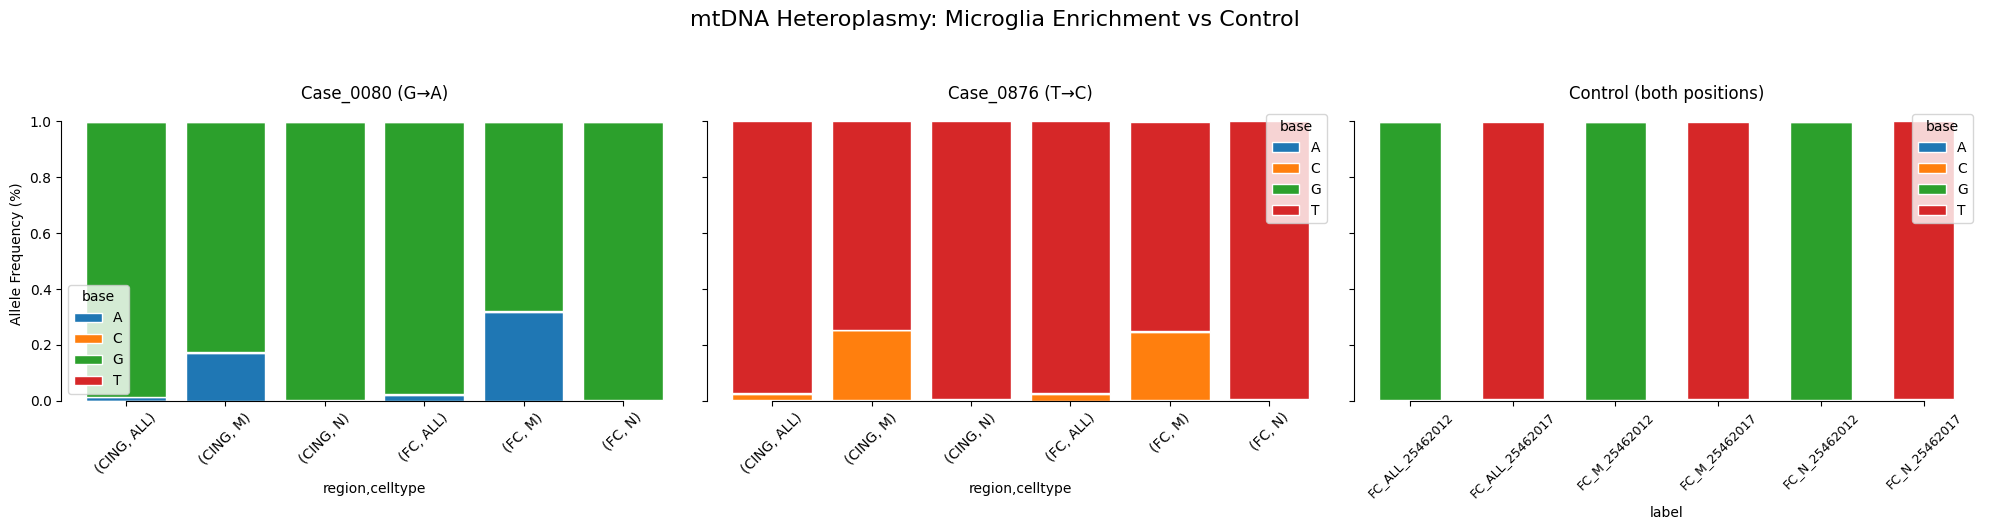

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

def plot_case(ax, df, case_id, pos_label, title):
    sub = df[(df['case'] == case_id) & (df['position'] == pos_label)]
    pivot = (sub.groupby(['region', 'celltype', 'base'])['frequency']
             .mean().reset_index()
             .pivot(index=['region','celltype'], columns='base', values='frequency')
             .fillna(0))
    pivot.plot(kind='bar', stacked=True, ax=ax, width=0.8, edgecolor='white')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)

def plot_control(ax, df, ctrl_case):
    ctrl_df = df[df['case'] == ctrl_case]
    # Unique labels: region_celltype_pos (e.g. "FC_ALL_2:25462012")
    ctrl_df['label'] = (ctrl_df['region'].astype(str) + '_' + 
                        ctrl_df['celltype'].astype(str) + '_' + 
                        ctrl_df['position'].str[-8:].str.replace(':', '_'))
    pivot = (ctrl_df.groupby(['label', 'base'])['frequency']
             .mean().reset_index()
             .pivot(index='label', columns='base', values='frequency')
             .fillna(0))
    pivot.plot(kind='bar', stacked=True, ax=ax, width=0.6, edgecolor='white')
    ax.set_title('Control (both positions)')
    ax.tick_params(axis='x', rotation=45, labelsize=9)

# Cases: 3 bars each
plot_case(axes[0], df_long, 'Case_0080', '2:25462012', 'Case_0080 (G→A)')
plot_case(axes[1], df_long, 'Case_0876', '2:25462017', 'Case_0876 (T→C)')

# Control: 6 bars (CING/FC × ALL/M/N × both pos)
plot_control(axes[2], df_long, 'Case_CTRL')

for ax in axes:
    ax.set_ylabel('Allele Frequency (%)')

sns.despine(trim=True)
plt.suptitle('mtDNA Heteroplasmy: Microglia Enrichment vs Control', fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig('heteroplasmy_3panel.png', dpi=300, bbox_inches='tight')
plt.show()


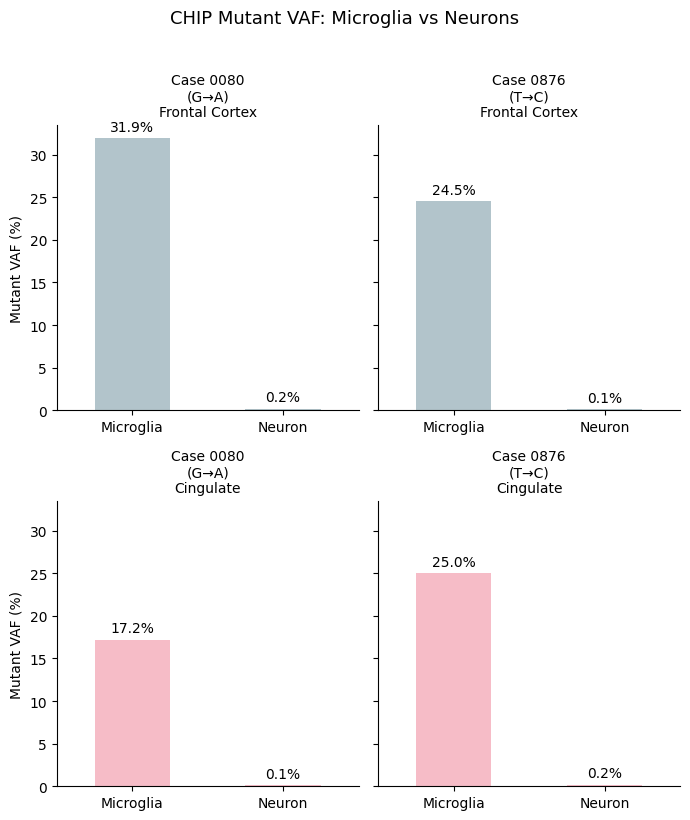

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

mut_base = {'Case_0080': 'A', 'Case_0876': 'C'}
case_labels = {'Case_0080': 'Case 0080\n(G→A)', 'Case_0876': 'Case 0876\n(T→C)'}
cell_labels = {'M': 'Microglia', 'N': 'Neuron'}
cell_order = ['Microglia', 'Neuron']
regions = ['FC', 'CING']
region_titles = {'FC': 'Frontal Cortex', 'CING': 'Cingulate'}
region_colors = {'FC': '#AEC6CF', 'CING': '#FFB3C1'}

plot_rows = []
for case, mbase in mut_base.items():
    sub = df_long[
        (df_long['case'] == case) &
        (df_long['celltype'].isin(['M', 'N'])) &
        (df_long['base'] == mbase)
    ]
    for _, r in sub.iterrows():
        plot_rows.append({
            'Case': case_labels[case],
            'Cell': cell_labels[r['celltype']],
            'Region': r['region'],
            'VAF': r['frequency'] * 100
        })

plot_df = pd.DataFrame(plot_rows)

fig, axes = plt.subplots(2, 2, figsize=(7, 8), sharey=True)

for row, region in enumerate(regions):
    for col, (case, case_label) in enumerate(case_labels.items()):
        ax = axes[row, col]
        sub = plot_df[(plot_df['Case'] == case_label) & (plot_df['Region'] == region)]
        sns.barplot(
            data=sub, x='Cell', y='VAF', order=cell_order,
            color=region_colors[region],
            ax=ax, errorbar='sd', capsize=0.05, width=0.5
        )
        for patch, cell in zip(ax.patches, cell_order):
            mean_val = sub[sub['Cell'] == cell]['VAF'].mean()
            ax.text(
                patch.get_x() + patch.get_width() / 2,
                patch.get_height() + 0.5,
                f'{mean_val:.1f}%',
                ha='center', va='bottom', fontsize=10, fontweight='normal'
            )
        ax.set_title(f"{case_label}\n{region_titles[region]}", fontsize=10)
        ax.set_xlabel('')
        ax.set_ylabel('Mutant VAF (%)' if col == 0 else '')

sns.despine()
plt.suptitle('CHIP Mutant VAF: Microglia vs Neurons', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('chip_vaf_FC_CING.png', dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_300072/2802772429.py:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


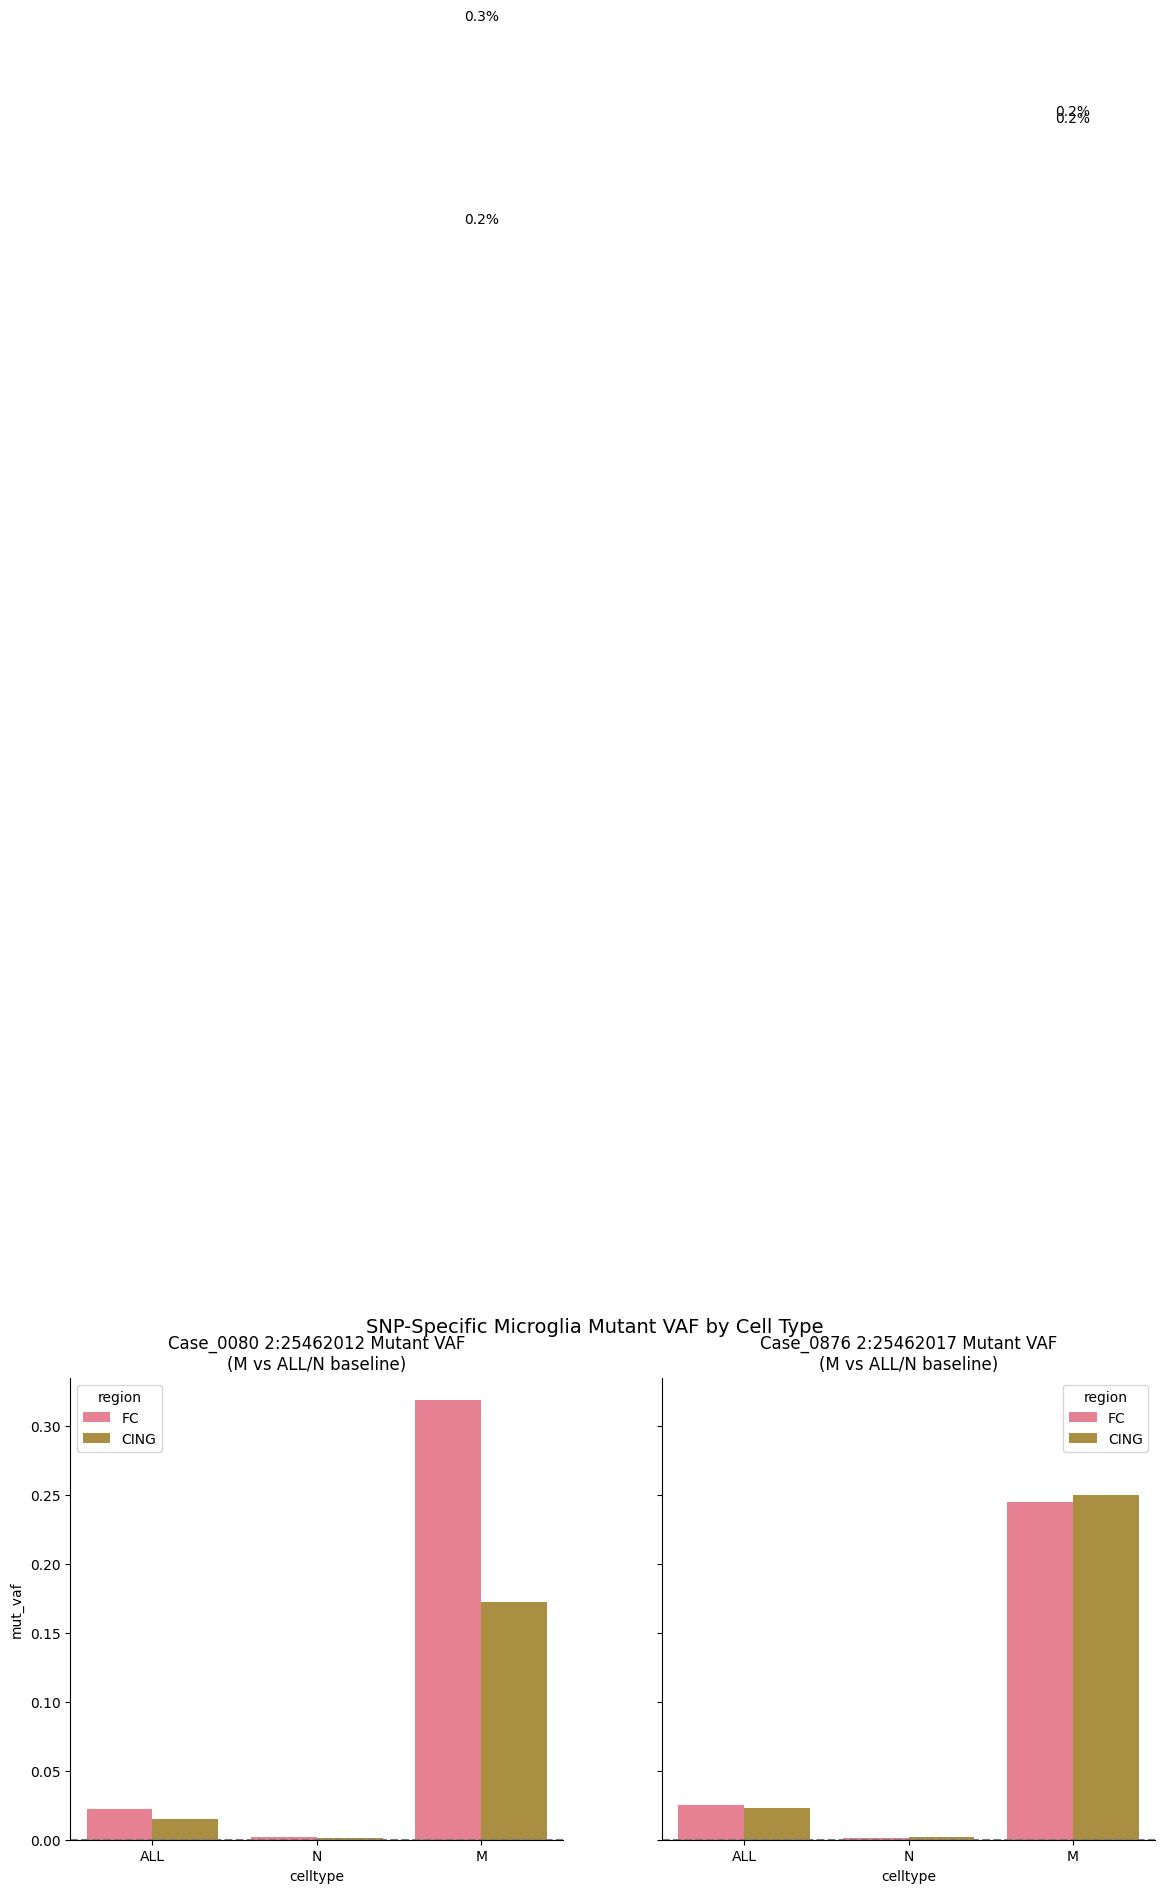

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for case_i, case in enumerate(['Case_0080', 'Case_0876']):
    pos = '2:25462012' if case=='Case_0080' else '2:25462017'
    mut_base = 'A' if case=='Case_0080' else 'C'
    
    ax = axes[case_i]
    # All celltypes mutant VAF grouped by region
    sub = df_long[(df_long['case']==case) & (df_long['position']==pos)]
    mut_data = []
    for region in ['FC', 'CING']:
        for celltype in ['ALL', 'N', 'M']:
            vaf = sub[(sub['region']==region) & (sub['celltype']==celltype) & (sub['base']==mut_base)]['frequency'].mean()
            mut_data.append({'region':region, 'celltype':celltype, 'mut_vaf':vaf})
    mut_df = pd.DataFrame(mut_data)
    sns.barplot(data=mut_df, x='celltype', y='mut_vaf', hue='region', ax=ax)
    ax.set_title(f'{case} {pos} Mutant VAF\n(M vs ALL/N baseline)')
    ax.axhline(0, color='gray', linestyle='--')
    # Annotate M bars
    for region in ['FC', 'CING']:
        m_vaf = mut_df[(mut_df['region']==region) & (mut_df['celltype']=='M')]['mut_vaf'].iloc[0]
        ax.text(2, m_vaf + 1, f'{m_vaf:.1f}%', ha='center')

plt.suptitle('SNP-Specific Microglia Mutant VAF by Cell Type', fontsize=14)
sns.despine()
plt.tight_layout()
plt.savefig('celltype_mutant_vaf.png', dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_300072/4100199859.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub['group'] = sub['celltype'].apply(lambda x: 'Microglia' if x=='M' else 'Non-M')
/tmp/ipykernel_300072/4100199859.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub['group'] = sub['celltype'].apply(lambda x: 'Microglia' if x=='M' else 'Non-M')


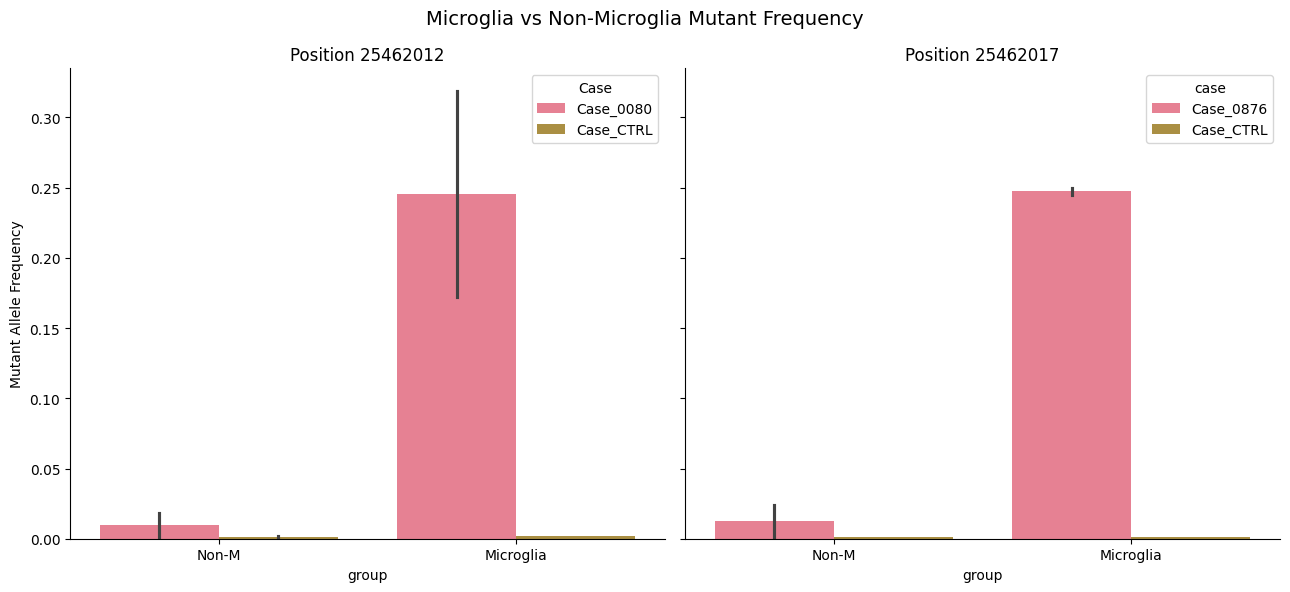

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

# Mutant alleles only
df_mut = df_long[
    ((df_long['position']=='2:25462012') & (df_long['base']=='A')) |
    ((df_long['position']=='2:25462017') & (df_long['base']=='C'))
]

for i, pos in enumerate(['2:25462012', '2:25462017']):
    sub = df_mut[df_mut['position'] == pos]
    sub['group'] = sub['celltype'].apply(lambda x: 'Microglia' if x=='M' else 'Non-M')
    
    sns.barplot(data=sub, x='group', y='frequency', hue='case', ax=axes[i])
    axes[i].set_title(f'Position {pos[-8:]}')
    axes[i].set_ylabel('Mutant Allele Frequency' if i==0 else '')

axes[0].legend(title='Case', frameon=True)
sns.despine()
plt.suptitle('Microglia vs Non-Microglia Mutant Frequency', fontsize=14)
plt.tight_layout()
plt.savefig('clean_microglia.png', dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_300072/1587073488.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_m.loc[(df_m['position']=='2:25462012') & (df_m['base']=='A'), 'mut_freq'] = df_m['frequency']



MICROGLIA MUTANT %
case       region  position  
Case_0080  CING    2:25462012    17.2
           FC      2:25462012    31.9
Case_0876  CING    2:25462017    25.0
           FC      2:25462017    24.5
Case_CTRL  FC      2:25462012     0.2
                   2:25462017     0.1
Name: mut_freq, dtype: float64


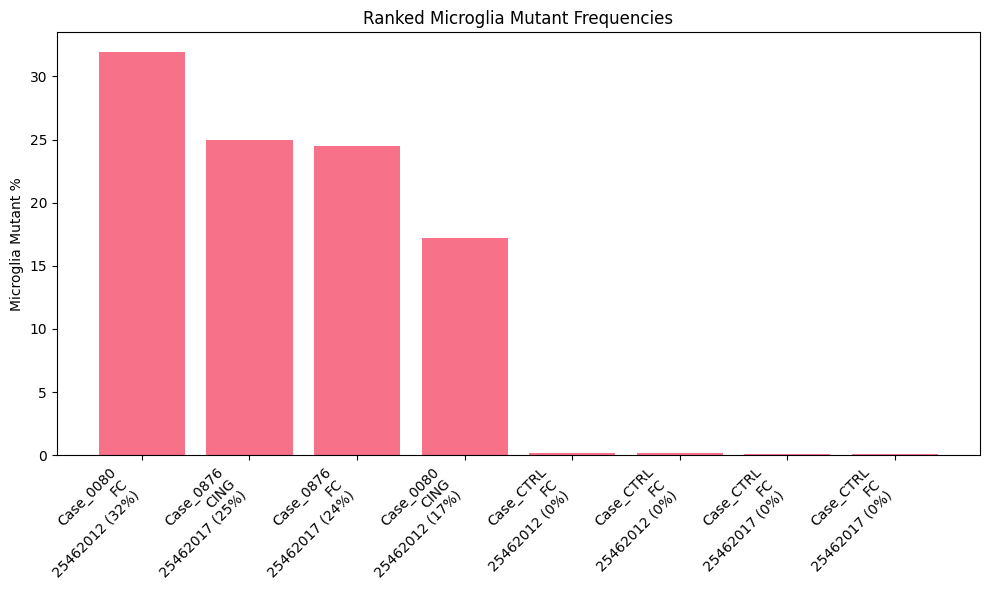

In [86]:
import matplotlib.pyplot as plt
import pandas as pd

# Clean microglia mutant data (your amplicon calls)
df_m = df_long[df_long['celltype']=='M']

# Position-specific mutants
df_m.loc[(df_m['position']=='2:25462012') & (df_m['base']=='A'), 'mut_freq'] = df_m['frequency']
df_m.loc[(df_m['position']=='2:25462017') & (df_m['base']=='C'), 'mut_freq'] = df_m['frequency']
df_m = df_m.dropna(subset=['mut_freq'])

# SIMPLE TABLE (no NaNs)
table = df_m.groupby(['case', 'region', 'position'])['mut_freq'].mean().round(3) * 100
print("\nMICROGLIA MUTANT %")
print(table)
table.to_csv('clean_microglia_table.csv')

# RANKED BARS (top-to-bottom)
top_values = df_m.nlargest(12, 'mut_freq')[['case', 'region', 'position', 'mut_freq']]
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(top_values)), top_values['mut_freq']*100)
ax.set_xticks(range(len(top_values)))
ax.set_xticklabels([f"{row.case}\n{row.region}\n{row.position[-8:]} ({row.mut_freq:.0%})" 
                   for _, row in top_values.iterrows()], 
                  rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Microglia Mutant %')
ax.set_title('Ranked Microglia Mutant Frequencies')
plt.tight_layout()
plt.savefig('ranked_microglia.png', dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_300072/1122813578.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_m.loc[(df_m['position']=='2:25462012') & (df_m['base']=='A'), 'mut'] = df_m['frequency']


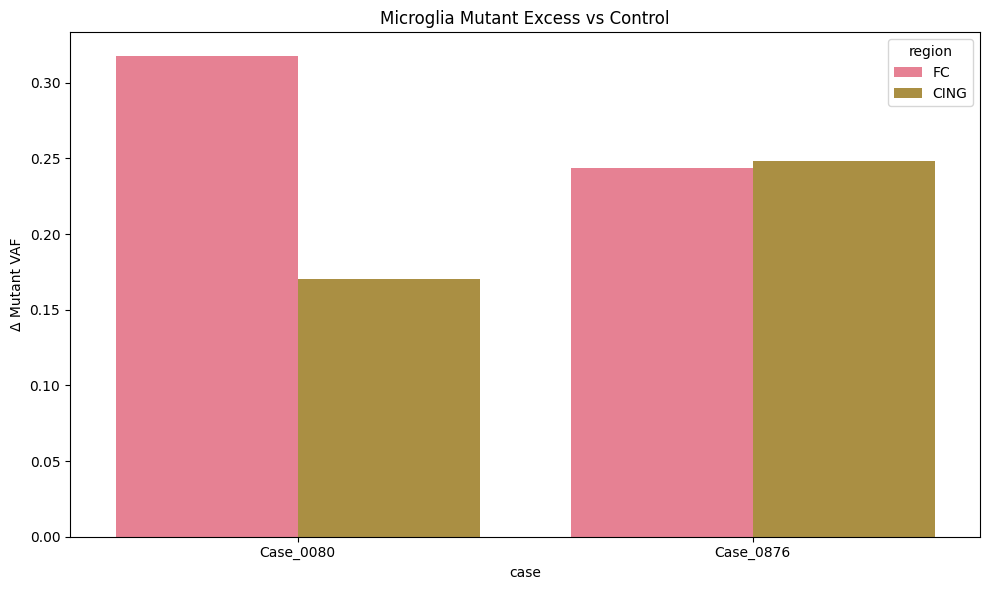

In [89]:
# Microglia mutant delta only
df_m = df_long[df_long['celltype']=='M']
df_m.loc[(df_m['position']=='2:25462012') & (df_m['base']=='A'), 'mut'] = df_m['frequency']
df_m.loc[(df_m['position']=='2:25462017') & (df_m['base']=='C'), 'mut'] = df_m['frequency']
df_m = df_m.dropna(subset=['mut'])

ctrl_mut = df_m[df_m['case']=='Case_CTRL']['mut'].mean()
df_m['delta'] = df_m['mut'] - ctrl_mut

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_m[df_m['case']!='Case_CTRL'], x='case', y='delta', hue='region')
ax.set_title('Microglia Mutant Excess vs Control')
ax.set_ylabel('Δ Mutant VAF')
plt.tight_layout()
plt.savefig('simple_delta.png', dpi=300)
plt.show()
